# Backtest LGBM Dual Implied Signed

Loads a saved LightGBM dual-head model pack (`lgbm_dual`), regenerates `LGBM_dual_implied_signed = long_pred - short_pred`, and runs a directional backtest on a validation OHLCV dataset.

Run all cells top-to-bottom.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from Learn.feature_codegen import load_generated_feature_module

warnings.filterwarnings('ignore')


In [2]:
# --- Configuration ---
MODEL_PACK_PATH = r'ModelPacks/EURUSD_M1_520weeks_LightGBM_20260709_spearman_prod_TP2.5_SL2.5_model.pkl'
DS_NAME = r'../data/EURUSD_M1_520weeks.csv'  # must match the instrument the pack (MODEL_PACK_PATH) was trained on
EVAL_START = None
EVAL_END = None
N_ROWS = 10_000
WARMUP_BARS = 7_000

TP_MULT = None  # Use model pack values
SL_MULT = None  # Use model pack values

# Production-parity execution settings
# NOTE: pred_long values are typically ~0.3-0.5, so threshold 0.95 is too high.
# The threshold sweep will find the optimal value, but start with a lower default.
TRADE_THRESHOLD   = 0.30
QUALITY_THRESHOLD = 0.00
PATIENCE = 1
ENTRY_BUFFER = 0.00001
MAX_POS_SIZE = None  # If not None, filters out trades with position_size > MAX_POS_SIZE
TRADING_HOURS = None  # If the pack provides a restricted session, we will use it.

# Directional backtest settings
LOOKAHEAD_BARS = 30

# --- For EURUSD, adjust as needed ---
TOP_PCTS = (0.01, 0.05, 0.10)
PIP_SIZE = 0.0001
RISK = 10.0
COMMISSION_USD = 0.00

# Analysis-only gates. Leave off for the production emulation path.
GATE_BREAKOUT = True
GATE_REGIME = False
GATE_DONCHIAN = False

assert os.path.exists(MODEL_PACK_PATH), f'Model pack not found: {MODEL_PACK_PATH}'
assert os.path.exists(DS_NAME), f'Dataset not found: {DS_NAME}'
print('Model pack:', MODEL_PACK_PATH)
print('Dataset:', DS_NAME)


Model pack: ModelPacks/EURUSD_M1_520weeks_LightGBM_20260709_spearman_prod_TP2.5_SL2.5_model.pkl
Dataset: ../data/EURUSD_M1_520weeks.csv


## Load Model Pack
Loads the pickled pack and extracts model, preprocessing, and metadata.

In [3]:
with open(MODEL_PACK_PATH, 'rb') as f:
    pack = pickle.load(f)

model = pack.get('model')
primary_model = pack.get('primary_model', model)
aux_models = pack.get('aux_models', {})
model_info = pack.get('model_info', {})
model_params = pack.get('model_params', {})
features = pack.get('features', [])
selected_features = pack.get('selected_features', None)

# Two-head design (Phase 3): a 3-class SL/TP/timeout classifier + a resolved-only magnitude
# regressor per side (long/short), plus model_choice ("lgbm" or "mlp") picking which trained
# candidate to use. Both candidates are always present in the pack regardless of model_choice.
two_head_classifiers = pack['two_head_classifiers']
two_head_regressors = pack['two_head_regressors']
model_choice = pack['model_choice']

# Features are reconstructed via the pack's standalone generated feature module (Phase 2),
# loaded with a sha256 integrity check - no more pickled feature_function closures or
# __main__-namespace lambda-detection hacks.
feature_file_path = pack['feature_file_path']
feature_file_hash = pack['feature_file_hash']
compute_features = load_generated_feature_module(feature_file_path, feature_file_hash)

preprocess_fn = pack['preprocess_function']
preprocess_args = {**pack['preprocess_args']}
saved_scaler = pack.get('scaler')
regime_params = pack.get('regime_params', None)
outcome_params = pack.get('outcome_params', None) or {}

TRADING_HOURS = pack.get('trading_hours', TRADING_HOURS)
PATIENCE = int(pack.get('patience', PATIENCE))

if TP_MULT is None:
    TP_MULT = outcome_params.get('tp_mult', None)
if SL_MULT is None:
    SL_MULT = outcome_params.get('sl_mult', None)

expected_model_features = int(getattr(primary_model, 'n_features_in_', 0) or 0)

print('Model type:', model_info.get('model_type', type(model).__name__))
print('Trained date:', model_info.get('date_trained', 'n/a'))
print('Feature count in pack:', len(features))
print('Model expected feature count:', expected_model_features)
print('Preprocess target columns:', preprocess_args.get('target_col', None))
print('Model choice:', model_choice)
print('Feature module:', feature_file_path)
print('Trading hours:', TRADING_HOURS)
print('Trade threshold:', TRADE_THRESHOLD)
print('Quality threshold:', QUALITY_THRESHOLD)
print('Patience:', PATIENCE)
print('Regime params (from pack):', regime_params)
type(model)


Model type: LightGBMRegressionPack
Trained date: 20260709
Feature count in pack: 66
Model expected feature count: 66
Preprocess target columns: ['long_quality', 'short_quality', 'signed_quality', 'tradeability_score', 'buy_win', 'sell_win', 'signed_win']
Model choice: {'long': 'lgbm', 'short': 'lgbm'}
Feature module: ModelPacks/generated_features/EURUSD_M1_520weeks_87b3e6714e.py
Trading hours: None
Trade threshold: 0.3
Quality threshold: 0.0
Patience: 1
Regime params (from pack): {'ma_period': 90, 'slope_smoothness': 50, 'regime_min_duration': 0, 'atr_window': 60, 'atr_lookback': 720, 'atr_percentile': 0.0, 'slope_threshold': 0}


lightgbm.sklearn.LGBMRegressor

In [4]:
# Use the pack's stored regime_params (matches training).
# Do NOT override with different values - this causes feature distribution shifts.
print('Using regime_params from model pack:', regime_params)

Using regime_params from model pack: {'ma_period': 90, 'slope_smoothness': 50, 'regime_min_duration': 0, 'atr_window': 60, 'atr_lookback': 720, 'atr_percentile': 0.0, 'slope_threshold': 0}


## Load and Prepare Evaluation Data
Applies the same feature and preprocessing pipeline saved in the pack.

In [5]:
df_raw = pd.read_csv(DS_NAME)
df_raw = df_raw.sort_values('Time').reset_index(drop=True)
df_raw['Time'] = pd.to_datetime(df_raw['Time'])


if EVAL_START is not None:
    df_raw = df_raw[df_raw['Time'] >= pd.to_datetime(EVAL_START)]
if EVAL_END is not None:
    df_raw = df_raw[df_raw['Time'] <= pd.to_datetime(EVAL_END)]
if N_ROWS is not None:
    df_raw = df_raw.tail(N_ROWS + WARMUP_BARS)

df_raw = df_raw.reset_index(drop=True)
print(f'Eval range: {df_raw.Time.iloc[0]} -> {df_raw.Time.iloc[-1]}')
print(f'Raw rows: {len(df_raw):,}')

# Use the pack's generated feature module (Phase 2/3). Its output is always exactly
# ['Time','Open','High','Low','Close','Volume'] + selected_features by construction, so no
# schema-guessing or column-dropping is needed here (unlike the old pickled feature_function path).
df_feat = compute_features(df_raw.copy(), include_mtf=True, regime_params=regime_params)
df_feat = df_feat.dropna().reset_index(drop=True)

# Keep only latest evaluation region after warmup
if WARMUP_BARS > 0:
    df_feat = df_feat.tail(N_ROWS).reset_index(drop=True)

# Compatibility patch: the training notebook adds a raw 'atr' column AFTER feature generation
# (for label computation), and since it's never excluded from the scaler's feature set, it
# legitimately ends up as one of the model's input columns (pack['features']). The generated
# feature module does not produce it, so reconstruct it here with the same fixed timeperiod=14
# the training notebook uses.
if ('atr' in features) and ('atr' not in df_feat.columns):
    from talib import ATR
    df_feat['atr'] = ATR(
        df_feat['High'].values.astype(float),
        df_feat['Low'].values.astype(float),
        df_feat['Close'].values.astype(float),
        timeperiod=14,
    )

print('Feature rows after engineering:', len(df_feat))
print('Feature schema length in pack:', len(features))

prep_args_eval = {**preprocess_args}
prep_args_eval['target_col'] = None
prep_args_eval['outcomes_col'] = None

_, _, _, _, _, df_eval_proc = preprocess_fn(
    df_feat,
    scaler=saved_scaler,
    return_df=True,
    **prep_args_eval,
)

# Build model matrix from processed dataframe and align to model expectations.
proc_feature_cols = [c for c in df_eval_proc.columns if c != 'Time']
desired_cols = [c for c in features if c in df_eval_proc.columns]
if not desired_cols:
    desired_cols = proc_feature_cols

X_eval_df = df_eval_proc[desired_cols].copy()

if expected_model_features > 0:
    if X_eval_df.shape[1] < expected_model_features:
        missing_proc_cols = [c for c in features if c not in df_eval_proc.columns]
        raise ValueError(
            f'Processed matrix has {X_eval_df.shape[1]} cols but model expects {expected_model_features}. '
            f'Missing processed features sample: {missing_proc_cols[:20]}'
        )
    if X_eval_df.shape[1] > expected_model_features:
        # Some packs carry a wider schema than the trained model; slice to fitted width.
        X_eval_df = X_eval_df.iloc[:, :expected_model_features]

X_eval = np.ascontiguousarray(X_eval_df.values)
time_eval = pd.to_datetime(df_eval_proc['Time']).reset_index(drop=True)

print('Prepared processed frame shape:', df_eval_proc.shape)
print('Inference matrix shape:', X_eval.shape)
print('Model expected features:', expected_model_features)
print('Inference columns used:', X_eval_df.shape[1])


Eval range: 2026-06-04 00:19:00+00:00 -> 2026-06-19 20:54:00+00:00
Raw rows: 17,000
Feature rows after engineering: 10000
Feature schema length in pack: 66
Prepared processed frame shape: (9986, 72)
Inference matrix shape: (9986, 66)
Model expected features: 66
Inference columns used: 66


## Regenerate LGBM Dual Implied Signed
Generates `long_pred`, `short_pred`, and `lgbm_dual_implied_signed`.

In [6]:
from Learn.Util import predict_two_head_mlp

def _predict_side(side, X):
    clf_info = two_head_classifiers[side]
    reg_info = two_head_regressors[side]
    choice = model_choice[side]

    if choice == 'lgbm':
        clf_model = clf_info['model']
        reg_model = reg_info['model']
        # LightGBM sorts integer class labels ascending by default (0=SL, 1=TP, 2=timeout per
        # the training notebook's label encoding) - verify rather than assume.
        assert list(clf_model.classes_) == [0, 1, 2], f'unexpected class order: {clf_model.classes_}'
        proba = clf_model.predict_proba(X)
        p_sl, p_tp = proba[:, 0], proba[:, 1]
        quality = reg_model.predict(X)
    else:
        mlp_model = clf_info['mlp_model']  # same object as reg_info['mlp_model'] - one model, two heads
        proba, quality = predict_two_head_mlp(mlp_model, X)
        p_sl, p_tp = proba[:, 0], proba[:, 1]

    return p_tp, p_sl, quality


pred_long, p_sl_long, quality_long = _predict_side('long', X_eval)
pred_short, p_sl_short, quality_short = _predict_side('short', X_eval)

# Combined prediction scheme: expected_side = P(TP|side) * magnitude - P(SL|side) * 1.0
# (an SL loss is defined as -1R by construction). pred_long/pred_short are genuine
# probabilities now (not regression scores standing in for probabilities).
expected_long = pred_long * quality_long - p_sl_long
expected_short = pred_short * quality_short - p_sl_short
pred_signed = expected_long - expected_short

pred_df = pd.DataFrame({
    'Time': time_eval,
    'pred_long': pred_long,
    'pred_short': pred_short,
    'pred_signed': pred_signed,
    'quality_long': quality_long,
    'quality_short': quality_short,
})

if TRADING_HOURS is not None:
    t_start = pd.to_datetime(TRADING_HOURS[0]).time()
    t_end = pd.to_datetime(TRADING_HOURS[1]).time()
    in_session = pred_df['Time'].dt.time.between(t_start, t_end, inclusive='left')
    pred_df = pred_df.loc[in_session].reset_index(drop=True)

# Quick diagnostic: check prediction distributions
print('Prediction distribution summary:')
print(f'  pred_long (P(TP|long)):  mean={pred_long.mean():.4f}, median={np.median(pred_long):.4f}, max={pred_long.max():.4f}')
print(f'  pred_short (P(TP|short)): mean={pred_short.mean():.4f}, median={np.median(pred_short):.4f}, max={pred_short.max():.4f}')
print(f'  % short > long: {np.mean(pred_short > pred_long)*100:.1f}%')
print(f'  % long > short: {np.mean(pred_long > pred_short)*100:.1f}%')
print(f'  pred_signed: mean={pred_signed.mean():.4f}, % positive={np.mean(pred_signed > 0)*100:.1f}%')

pred_df.head()


Prediction distribution summary:
  pred_long (P(TP|long)):  mean=0.3959, median=0.4017, max=0.5069
  pred_short (P(TP|short)): mean=0.3960, median=0.3946, max=0.5064
  % short > long: 49.9%
  % long > short: 50.1%
  pred_signed: mean=0.0282, % positive=59.1%


,Time,pred_long,pred_short,pred_signed,quality_long,quality_short
0,2026-06-10 21:50:00+00:00,0.341048,0.364861,-0.066928,0.596762,0.638973
1,2026-06-10 21:51:00+00:00,0.434138,0.238145,0.366768,0.679340,0.522229
2,2026-06-10 21:52:00+00:00,0.390243,0.364963,-0.000219,0.636051,0.734325
3,2026-06-10 21:53:00+00:00,0.242461,0.360043,-0.233544,0.517644,0.616441
4,2026-06-10 21:54:00+00:00,0.435715,0.364807,0.137254,0.687218,0.612358


array([[<Axes: title={'center': 'pred_long'}>,
        <Axes: title={'center': 'pred_short'}>],
       [<Axes: title={'center': 'quality_long'}>,
        <Axes: title={'center': 'quality_short'}>]], dtype=object)

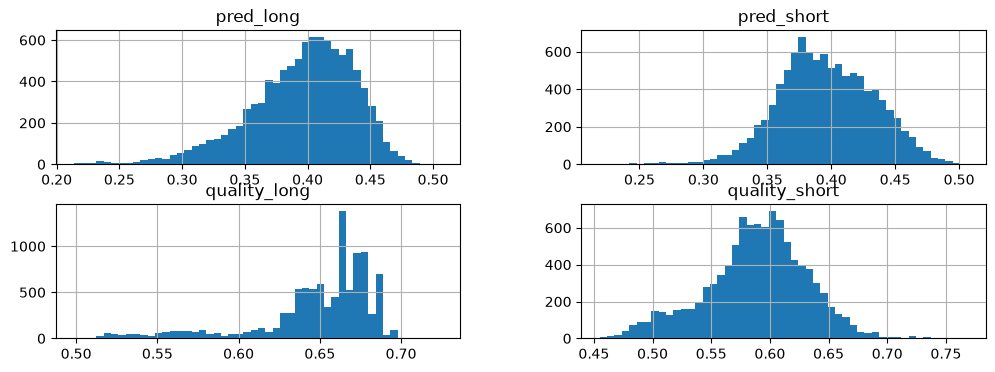

In [7]:
pred_df[['pred_long', 'pred_short', 'quality_long', 'quality_short']].hist(bins=50, figsize=(12, 4))

## Generate Trade Entries

In [8]:
def prediction_to_signal(row, trade_threshold=TRADE_THRESHOLD, quality_threshold=QUALITY_THRESHOLD, trading_hours=TRADING_HOURS):
    # Convert raw model outputs into a production-style trade signal.
    #  1 -> buy stop order
    # -1 -> sell stop order
    #  0 -> no trade
    if trading_hours is not None:
        t_start = pd.to_datetime(trading_hours[0]).time()
        t_end = pd.to_datetime(trading_hours[1]).time()
        in_restricted_hours = t_start <= row['Time'].time() <= t_end
    else:
        in_restricted_hours = False

    quality = abs(row['pred_signed'])
    buy_ready = (row['pred_long'] >= trade_threshold) and (quality >= quality_threshold)
    sell_ready = (row['pred_short'] >= trade_threshold) and (quality >= quality_threshold)

    if in_restricted_hours:
        signal = 0
        reason = 'restricted_hours'
    elif buy_ready:
        signal = 1
        reason = 'buy_thresholds_met'
    elif sell_ready:
        signal = -1
        reason = 'sell_thresholds_met'
    else:
        signal = 0
        reason = 'below_threshold'

    return pd.Series({
        'quality': quality,
        'in_restricted_hours': in_restricted_hours,
        'buy_ready': buy_ready,
        'sell_ready': sell_ready,
        'raw_signal': signal,
        'signal_reason': reason,
    })


df = df_raw.merge(pred_df, on='Time', how='inner').sort_values('Time').reset_index(drop=True)
signal_cols = df.apply(
    prediction_to_signal,
    axis=1,
    trade_threshold=TRADE_THRESHOLD,
    quality_threshold=QUALITY_THRESHOLD,
    trading_hours=TRADING_HOURS,
)
df = pd.concat([df, signal_cols], axis=1)
df['signal'] = df['raw_signal'].astype(int)
df_gated = df.copy()

print(f'Raw signal counts: {df_gated["raw_signal"].value_counts().to_dict()}')
print(f'In restricted hours: {int(df_gated["in_restricted_hours"].sum()):,} rows')
print(df_gated[['Time', 'pred_long', 'pred_short', 'pred_signed', 'quality', 'raw_signal', 'signal_reason']].head())


Raw signal counts: {1: 9727, -1: 259}
In restricted hours: 0 rows
                       Time  pred_long  pred_short  pred_signed   quality  \
0 2026-06-10 21:50:00+00:00   0.341048    0.364861    -0.066928  0.066928   
1 2026-06-10 21:51:00+00:00   0.434138    0.238145     0.366768  0.366768   
2 2026-06-10 21:52:00+00:00   0.390243    0.364963    -0.000219  0.000219   
3 2026-06-10 21:53:00+00:00   0.242461    0.360043    -0.233544  0.233544   
4 2026-06-10 21:54:00+00:00   0.435715    0.364807     0.137254  0.137254   

   raw_signal        signal_reason  
0           1   buy_thresholds_met  
1           1   buy_thresholds_met  
2           1   buy_thresholds_met  
3          -1  sell_thresholds_met  
4           1   buy_thresholds_met  


In [9]:
# The live engine does not apply the old regime / breakout / Donchian gates.
# We keep the plotting dataframe separate, but the production-emulation signal
# stream is the raw strategy signal stream from cell 13.
df_gated = df.copy()
raw_counts = df_gated['raw_signal'].value_counts().rename({-1: 'SELL', 0: 'HOLD', 1: 'BUY'})
gate_counts = df_gated['signal'].value_counts().rename({-1: 'SELL', 0: 'HOLD', 1: 'BUY'})
summary = pd.DataFrame({'Raw': raw_counts, 'Gated': gate_counts}).fillna(0).astype(int)
summary['Removed'] = summary['Raw'] - summary['Gated']
print(f"\n{summary.to_string()}")



       Raw  Gated  Removed
BUY   9727   9727        0
SELL   259    259        0


In [10]:
from talib import EMA as talib_EMA
from Learn.labels import super_smoother
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Build chart dataframe ─────────────────────────────────────────────────────
df_chart = df[['Time', 'Open', 'High', 'Low', 'Close', 'Volume']].copy().tail(10_000).reset_index(drop=True)
sig_cols = ['Time', 'signal', 'pred_long', 'pred_short', 'pred_signed']
df_chart = df_chart.merge(df_gated[sig_cols], on='Time', how='left')
df_chart['signal'] = df_chart['signal'].fillna(0).astype(int)
# df_chart['regime'] = df_chart['regime'].fillna(0)

df_chart['z_score'] = (df_chart['Close'] - df_chart['Close'].rolling(100).mean()) / df_chart['Close'].rolling(100).std()
df_chart['z_score_binary'] = (df_chart['z_score'] > 0).astype(int)

# ── Compute regime EMA and slope (same as causal_market_regime internals) ──────
ma_period        = regime_params.get('ma_period', 21) if regime_params else 21
slope_smoothness = regime_params.get('slope_smoothness', 1) if regime_params else 1

ma_arr = talib_EMA(df_chart['Close'].values.astype(float), timeperiod=ma_period)
ma_s   = pd.Series(ma_arr, index=df_chart.index)
slope  = ma_s.diff() / ma_s
df_chart['regime_ma'] = ma_s
df_chart['slope_sm']  = super_smoother(slope, period=max(slope_smoothness, 2))

buy_bars  = df_chart[df_chart['signal'] ==  1]
sell_bars = df_chart[df_chart['signal'] == -1]

atr_series = df_chart['High'].rolling(14).mean() - df_chart['Low'].rolling(14).mean()
offset     = float(atr_series.mean()) * 0.5

vol_colors = np.where(df_chart['Close'] >= df_chart['Open'], '#26a69a', '#ef5350')

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.15, 0.20], vertical_spacing=0.02)

# ── Row 1: Candlesticks ───────────────────────────────────────────────────────
fig.add_trace(go.Candlestick(
    x=df_chart['Time'], open=df_chart['Open'], high=df_chart['High'],
    low=df_chart['Low'], close=df_chart['Close'], name='OHLCV',
    increasing_line_color='#26a69a', decreasing_line_color='#ef5350',
    increasing_fillcolor='#26a69a', decreasing_fillcolor='#ef5350',
    line=dict(width=1), hoverinfo='skip'), row=1, col=1)

# ── Row 1: BUY / SELL signal markers ─────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=buy_bars['Time'], y=buy_bars['Low'] - offset, mode='markers',
    marker=dict(symbol='triangle-up', size=9, color='#00e676',
                line=dict(color='darkgreen', width=0.8)),
    name='BUY signal', hoverinfo='skip'), row=1, col=1)

fig.add_trace(go.Scatter(
    x=sell_bars['Time'], y=sell_bars['High'] + offset, mode='markers',
    marker=dict(symbol='triangle-down', size=9, color='#ff1744',
                line=dict(color='darkred', width=0.8)),
    name='SELL signal', hoverinfo='skip'), row=1, col=1)

# ── Row 2: Volume ─────────────────────────────────────────────────────────────
fig.add_trace(go.Bar(x=df_chart['Time'], y=df_chart['Volume'],
    marker_color=vol_colors, marker_line_width=0,
    name='Volume', hoverinfo='skip', showlegend=False), row=2, col=1)

# ── Row 3: Z-Score ───────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=df_chart['Time'], y=df_chart['z_score_binary'],
    mode='lines', line=dict(width=1, color='#ffcb6b'),
    name='Z-Score Gate', hoverinfo='skip',
), row=3, col=1)

fig.add_hline(y=0, line=dict(color='#555555', width=0.8, dash='dash'), row=3, col=1)

fig.update_layout(
    xaxis=dict(rangeslider=dict(visible=False),
               rangeselector=dict(buttons=[
                   dict(count=1, label='1d', step='day', stepmode='backward'),
                   dict(count=7, label='1w', step='day', stepmode='backward'),
                   dict(count=1, label='1mo', step='month', stepmode='backward'),
                   dict(count=3, label='3mo', step='month', stepmode='backward'),
                   dict(step='all', label='All'),
               ]), type='date'),
    xaxis3=dict(title='Time'),
    yaxis=dict(title='Price', fixedrange=False),
    yaxis2=dict(title='Volume', fixedrange=True),
    yaxis3=dict(title='Indicator', fixedrange=True),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=1300, margin=dict(l=60, r=20, t=80, b=60), hovermode=False,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    xaxis_gridcolor='#333', yaxis_gridcolor='#333',
    xaxis2_gridcolor='#333', yaxis2_gridcolor='#333',
    xaxis3_gridcolor='#333', yaxis3_gridcolor='#333',
)
fig.show()


## P&L Analysis

Simulates each gated trade signal against actual forward price action using fixed R:R model.
P&L is independent of where TP/SL triggered — a trade that hits TP earns REWARD = TP_MULT,
a trade that hits SL incurs RISK = SL_MULT.

In [11]:
df_gated['signal'].value_counts()

signal
 1    9727
-1     259
Name: count, dtype: int64

In [12]:
import talib

outcome_params = pack.get('outcome_params', {}) or {}
atr_window = int(outcome_params.get('atr_window', 14))
tp_mult = outcome_params.get('tp_mult', 2.5) if TP_MULT is None else TP_MULT
sl_mult = outcome_params.get('sl_mult', 2.5) if SL_MULT is None else SL_MULT

print(f"Production emulation: ATR={atr_window}")
print(f"Fixed R:R: TP_MULT={tp_mult:.2f} | SL_MULT={sl_mult:.2f} | R:R={tp_mult/sl_mult:.2f}")
print(f"Risk per trade: ${RISK:.2f} | Commission: ${COMMISSION_USD:.2f} per lot per round trip")


def _in_restricted_hours(ts, trading_hours):
    if trading_hours is None:
        return False
    start = pd.to_datetime(trading_hours[0]).time()
    end = pd.to_datetime(trading_hours[1]).time()
    current = pd.to_datetime(ts).time()
    return start <= current <= end


def simulate_production_trades(signal_frame, *, atr_window, tp_mult, sl_mult, patience, entry_buffer, trading_hours,
                                risk_per_trade=RISK, commission_per_lot=COMMISSION_USD,
                                max_pos_size=None):
    df_sim = signal_frame.copy().reset_index(drop=True)
    df_sim['atr'] = talib.ATR(df_sim['High'], df_sim['Low'], df_sim['Close'], timeperiod=atr_window)

    trades = []
    pending_order = None
    open_position = None
    countdown = 0

    for i, row in df_sim.iterrows():
        bar_time = row['Time']
        bar_open = float(row['Open'])
        bar_high = float(row['High'])
        bar_low = float(row['Low'])
        bar_close = float(row['Close'])
        had_pending = pending_order is not None
        had_open = open_position is not None

        if countdown > 0:
            countdown -= 1

        # Pass 1: fill pending stop orders before expiry.
        if pending_order is not None:
            side = pending_order['side']
            entry = pending_order['entry']
            if side == 'buy' and bar_high >= entry:
                fill_price = bar_open if bar_open >= entry else entry
                open_position = {
                    **pending_order,
                    'fill_time': bar_time,
                    'fill_price': fill_price,
                    'entry_index': i,
                }
                pending_order = None
            elif side == 'sell' and bar_low <= entry:
                fill_price = bar_open if bar_open <= entry else entry
                open_position = {
                    **pending_order,
                    'fill_time': bar_time,
                    'fill_price': fill_price,
                    'entry_index': i,
                }
                pending_order = None

        # Pass 2: expire any remaining unfilled pending orders.
        if pending_order is not None and bar_time >= pending_order['expires_at']:
            pending_order = None

        # Pass 3: update open positions using the same SL-first logic as the live executor.
        if open_position is not None:
            side = open_position['side']
            fill_price = float(open_position['fill_price'])
            sl = float(open_position['sl'])
            tp = float(open_position['tp'])
            position_size = float(open_position['position_size'])
            close_price = None
            close_reason = None

            if side == 'buy':
                sl_hit = sl > 0 and bar_low <= sl
                tp_hit = tp > 0 and bar_high >= tp
                if sl_hit:
                    close_price = min(sl, bar_open)
                    close_reason = 'sl'
                elif tp_hit:
                    close_price = tp
                    close_reason = 'tp'
            else:
                sl_hit = sl > 0 and bar_high >= sl
                tp_hit = tp > 0 and bar_low <= tp
                if sl_hit:
                    close_price = max(sl, bar_open)
                    close_reason = 'sl'
                elif tp_hit:
                    close_price = tp
                    close_reason = 'tp'

            if close_price is not None:
                # Dynamic position sizing: P&L is based on fixed RISK per trade.
                # A loss (SL hit) costs exactly risk_per_trade.
                # A win (TP hit) pays risk_per_trade * (tp_mult / sl_mult).
                if close_reason == 'tp':
                    raw_usd = risk_per_trade * (tp_mult / sl_mult)
                elif close_reason == 'sl':
                    raw_usd = -risk_per_trade
                else:
                    # Fallback for eod/other: compute from actual price movement
                    if side == 'buy':
                        price_move = close_price - fill_price
                    else:
                        price_move = fill_price - close_price
                    raw_usd = price_move * position_size * 100_000
                commission = position_size * commission_per_lot
                net_usd = raw_usd - commission
                signal_row = open_position['signal_row']
                trades.append({
                    'signal_time': open_position['signal_time'],
                    'fill_time': open_position['fill_time'],
                    'exit_time': bar_time,
                    'direction': 'BUY' if side == 'buy' else 'SELL',
                    'signal': 1 if side == 'buy' else -1,
                    'entry': round(fill_price, 5),
                    'tp': round(tp, 5),
                    'sl': round(sl, 5),
                    'exit_price': round(close_price, 5),
                    'outcome': close_reason,
                    'position_size': round(position_size, 4),
                    'raw_usd': round(raw_usd, 2),
                    'commission': round(commission, 2),
                    'net_usd': round(net_usd, 2),
                    'atr_pips': round(float(open_position['atr']) / PIP_SIZE, 2),
                    'hold_bars': int(i - open_position['entry_index']),
                    'buy_prob': float(signal_row['pred_long']),
                    'sell_prob': float(signal_row['pred_short']),
                    'quality': float(signal_row['quality']),
                })
                open_position = None

        # Production parity: if we started the bar with a pending order or open
        # position, we do not consider a new signal on the same bar.
        if had_pending or had_open or countdown > 0:
            continue
        if _in_restricted_hours(bar_time, trading_hours):
            continue
        if pd.isna(row['atr']):
            continue

        signal = int(row['raw_signal'])
        if signal == 0:
            continue

        if signal == 1:
            side = 'buy'
            entry = bar_high + entry_buffer
            tp = bar_high + (tp_mult * float(row['atr']))
            sl = bar_high - (sl_mult * float(row['atr']))
        else:
            side = 'sell'
            entry = bar_low - entry_buffer
            tp = bar_low - (tp_mult * float(row['atr']))
            sl = bar_low + (sl_mult * float(row['atr']))

        # Calculate dynamic position size based on fixed RISK
        sl_distance = abs(float(entry) - float(sl))
        position_size = (risk_per_trade / sl_distance) / 100_000.0 if sl_distance > 0 else 0.0

        # Filter out trades where position size exceeds max_pos_size
        if max_pos_size is not None and position_size > max_pos_size:
            continue

        pending_order = {
            'signal_time': bar_time,
            'side': side,
            'entry': float(entry),
            'tp': float(tp),
            'sl': float(sl),
            'atr': float(row['atr']),
            'position_size': position_size,
            'signal_row': row,
            'expires_at': bar_time + pd.Timedelta(minutes=patience),
        }
        countdown = patience

    # Force-close any residual open position at the final close so P&L is realised.
    if open_position is not None:
        last_row = df_sim.iloc[-1]
        fill_price = float(open_position['fill_price'])
        close_price = float(last_row['Close'])
        position_size = float(open_position['position_size'])
        if open_position['side'] == 'buy':
            price_move = close_price - fill_price
        else:
            price_move = fill_price - close_price
        raw_usd = price_move * position_size * 100_000
        commission = position_size * commission_per_lot
        net_usd = raw_usd - commission
        signal_row = open_position['signal_row']
        trades.append({
            'signal_time': open_position['signal_time'],
            'fill_time': open_position['fill_time'],
            'exit_time': last_row['Time'],
            'direction': 'BUY' if open_position['side'] == 'buy' else 'SELL',
            'signal': 1 if open_position['side'] == 'buy' else -1,
            'entry': round(fill_price, 5),
            'tp': round(float(open_position['tp']), 5),
            'sl': round(float(open_position['sl']), 5),
            'exit_price': round(close_price, 5),
            'outcome': 'eod',
            'position_size': round(position_size, 4),
            'raw_usd': round(raw_usd, 2),
            'commission': round(commission, 2),
            'net_usd': round(net_usd, 2),
            'atr_pips': round(float(open_position['atr']) / PIP_SIZE, 2),
            'hold_bars': int(len(df_sim) - 1 - open_position['entry_index']),
            'buy_prob': float(signal_row['pred_long']),
            'sell_prob': float(signal_row['pred_short']),
            'quality': float(signal_row['quality']),
        })

    trades_df = pd.DataFrame(trades)
    return df_sim, trades_df


df_sim, trades = simulate_production_trades(
    df_gated,
    atr_window=atr_window,
    tp_mult=tp_mult,
    sl_mult=sl_mult,
    patience=PATIENCE,
    entry_buffer=ENTRY_BUFFER,
    trading_hours=TRADING_HOURS,
    risk_per_trade=RISK,
    commission_per_lot=COMMISSION_USD,
    max_pos_size=MAX_POS_SIZE,
)

print(f'Trades executed: {len(trades):,}')
if len(trades) > 0:
    display(trades.head())


Production emulation: ATR=60
Fixed R:R: TP_MULT=2.50 | SL_MULT=2.50 | R:R=1.00
Risk per trade: $10.00 | Commission: $0.00 per lot per round trip
Trades executed: 528


,signal_time,fill_time,exit_time,direction,signal,entry,tp,sl,exit_price,outcome,position_size,raw_usd,commission,net_usd,atr_pips,hold_bars,buy_prob,sell_prob,quality
0,2026-06-10 22:50:00+00:00,2026-06-10 22:51:00+00:00,2026-06-10 22:55:00+00:00,BUY,1,1.15353,1.15378,1.15326,1.15326,sl,0.3715,-10.0,0.0,-10.0,1.04,4,0.368431,0.351815,0.044534
1,2026-06-10 22:58:00+00:00,2026-06-10 22:59:00+00:00,2026-06-10 23:06:00+00:00,SELL,-1,1.15299,1.15274,1.15326,1.15274,tp,0.3694,10.0,0.0,10.0,1.04,7,0.233391,0.401884,0.284658
2,2026-06-10 23:09:00+00:00,2026-06-10 23:10:00+00:00,2026-06-10 23:19:00+00:00,BUY,1,1.15278,1.15304,1.15250,1.15304,tp,0.3577,10.0,0.0,10.0,1.08,9,0.451476,0.366832,0.180620
3,2026-06-10 23:22:00+00:00,2026-06-10 23:23:00+00:00,2026-06-10 23:26:00+00:00,BUY,1,1.15318,1.15348,1.15284,1.15348,tp,0.3070,10.0,0.0,10.0,1.26,3,0.432443,0.375288,0.128412
4,2026-06-10 23:35:00+00:00,2026-06-10 23:36:00+00:00,2026-06-10 23:43:00+00:00,BUY,1,1.15346,1.15379,1.15311,1.15379,tp,0.2869,10.0,0.0,10.0,1.35,7,0.444713,0.310953,0.274282


,Trades,Wins (TP),Losses (SL),EOD Close,Win Rate %,Net USD ($),Avg USD ($),Best Trade ($),Worst Trade ($),Commission ($)
ALL,528.0,265.0,262.0,1.0,50.3,22.3,0.04,10.0,-10.0,0.0
BUY,508.0,252.0,255.0,1.0,49.7,-37.7,-0.07,10.0,-10.0,0.0
SELL,20.0,13.0,7.0,0.0,65.0,60.0,3.00,10.0,-10.0,0.0


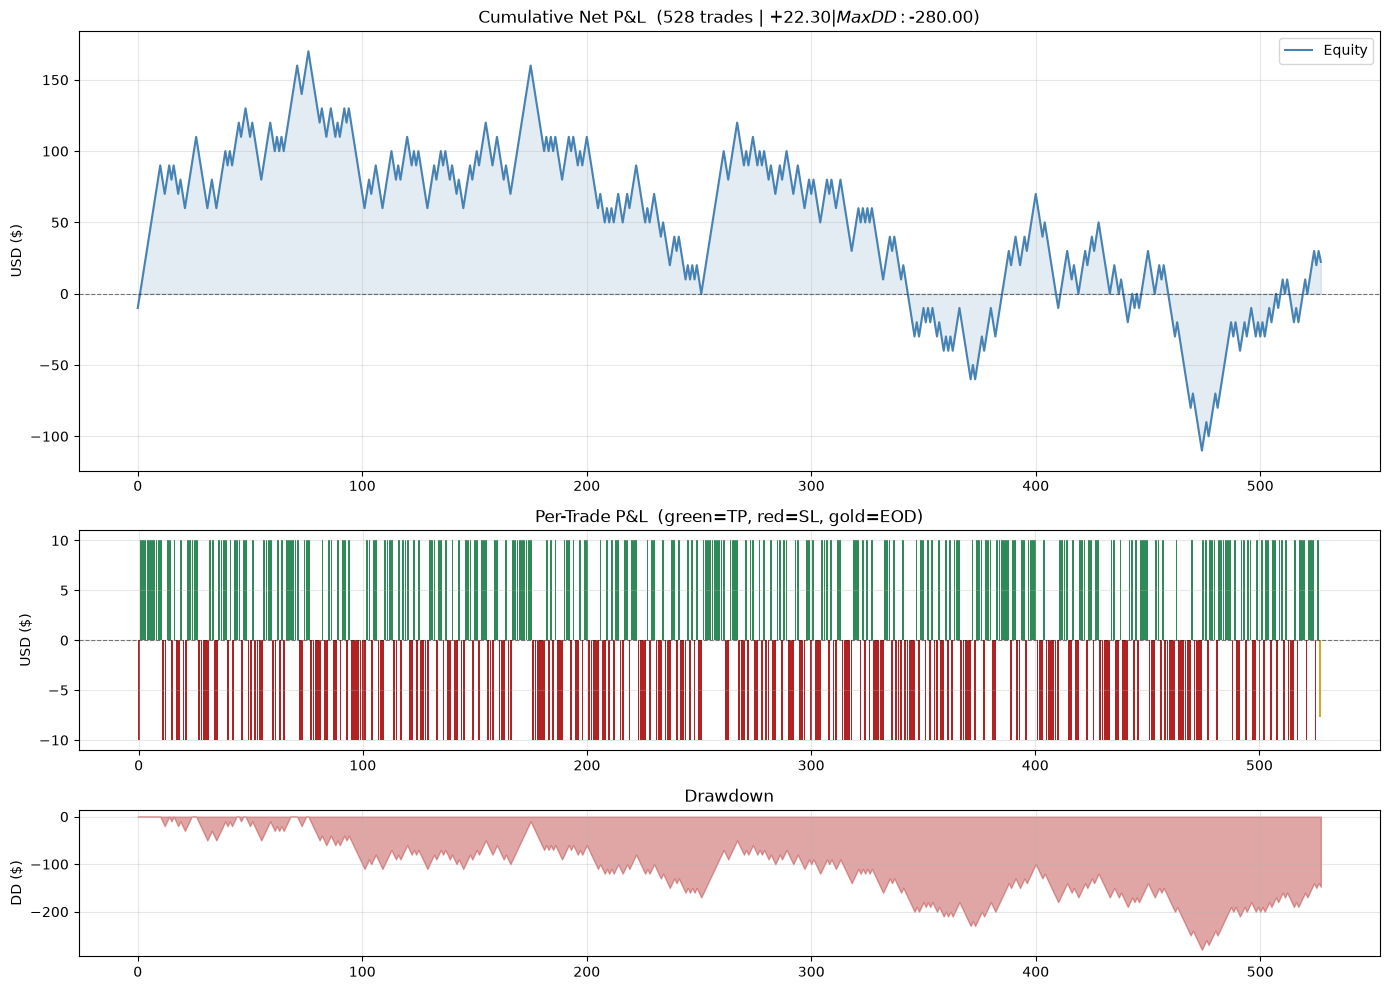

In [13]:
if len(trades) == 0:
    print("No trades to display.")
else:
    def _summary_stats(df):
        if len(df) == 0:
            return {}
        wins = (df['outcome'] == 'tp').sum()
        losses = (df['outcome'] == 'sl').sum()
        total_closed = wins + losses
        win_rate = (wins / total_closed * 100) if total_closed > 0 else 0.0
        return {
            'Trades':          len(df),
            'Wins (TP)':       wins,
            'Losses (SL)':     losses,
            'EOD Close':       (df['outcome'] == 'eod').sum(),
            'Win Rate %':      round(win_rate, 1),
            'Net USD ($)':     round(df['net_usd'].sum(), 2),
            'Avg USD ($)':     round(df['net_usd'].mean(), 2),
            'Best Trade ($)':  round(df['net_usd'].max(), 2),
            'Worst Trade ($)': round(df['net_usd'].min(), 2),
            'Commission ($)':  round(df['commission'].sum(), 2),
        }

    stats = pd.DataFrame({
        'ALL':  _summary_stats(trades),
        'BUY':  _summary_stats(trades[trades['direction'] == 'BUY']),
        'SELL': _summary_stats(trades[trades['direction'] == 'SELL']),
    }).T
    display(stats)

    trades_sorted = trades.rename(columns={'signal_time': 'time'}).sort_values('time').reset_index(drop=True)
    trades_sorted['cum_usd'] = trades_sorted['net_usd'].cumsum()
    running_max = trades_sorted['cum_usd'].cummax()
    drawdown    = trades_sorted['cum_usd'] - running_max
    max_dd      = drawdown.min()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1.5, 1]})

    axes[0].plot(trades_sorted.index, trades_sorted['cum_usd'], color='steelblue', lw=1.5, label='Equity')
    axes[0].fill_between(trades_sorted.index, trades_sorted['cum_usd'], alpha=0.15, color='steelblue')
    axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[0].set_title(
        f'Cumulative Net P&L  ({len(trades):,} trades | ${trades_sorted["cum_usd"].iloc[-1]:+,.2f} | MaxDD: ${max_dd:.2f})')
    axes[0].set_ylabel('USD ($)'); axes[0].grid(alpha=0.3); axes[0].legend()

    colours = trades_sorted['outcome'].map({'tp': 'seagreen', 'sl': 'firebrick', 'eod': 'goldenrod'})
    axes[1].bar(trades_sorted.index, trades_sorted['net_usd'], color=colours, width=0.8)
    axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[1].set_ylabel('USD ($)')
    axes[1].set_title('Per-Trade P&L  (green=TP, red=SL, gold=EOD)')
    axes[1].grid(alpha=0.3)

    axes[2].fill_between(trades_sorted.index, drawdown, 0, color='firebrick', alpha=0.4)
    axes[2].set_ylabel('DD ($)'); axes[2].set_title('Drawdown'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Threshold Sweep

In [14]:
signal_thresholds = [0.99, 0.95, 0.90, 0.80, 0.70, 0.60, 0.50]
quality_thresholds = [0.00, 0.25, 0.50, 0.60, 0.70]

results = []
for quality_threshold in quality_thresholds:
    for signal_threshold in signal_thresholds:
        trial_frame = df_raw.merge(pred_df, on='Time', how='inner').sort_values('Time').reset_index(drop=True)
        trial_signal_cols = trial_frame.apply(
            prediction_to_signal,
            axis=1,
            trade_threshold=signal_threshold,
            quality_threshold=quality_threshold,
            trading_hours=TRADING_HOURS,
        )
        trial_frame = pd.concat([trial_frame, trial_signal_cols], axis=1)
        trial_frame['signal'] = trial_frame['raw_signal'].astype(int)

        trial_sim, trial_trades = simulate_production_trades(
            trial_frame,
            atr_window=atr_window,
            tp_mult=tp_mult,
            sl_mult=sl_mult,
            patience=PATIENCE,
            entry_buffer=ENTRY_BUFFER,
            trading_hours=TRADING_HOURS,
            risk_per_trade=RISK,
            commission_per_lot=COMMISSION_USD,
            max_pos_size=MAX_POS_SIZE,
        )

        trial_net = float(trial_trades['net_usd'].sum()) if len(trial_trades) else 0.0
        trial_win = float((trial_trades['outcome'] == 'tp').mean() * 100) if len(trial_trades) else 0.0
        trial_avg = float(trial_trades['net_usd'].mean()) if len(trial_trades) else 0.0
        results.append({
            'trade_threshold': signal_threshold,
            'quality_threshold': quality_threshold,
            'trades': int(len(trial_trades)),
            'win_rate_pct': round(trial_win, 1),
            'avg_net_usd': round(trial_avg, 2),
            'net_usd': round(trial_net, 2),
        })

results_df = pd.DataFrame(results).sort_values(['net_usd', 'win_rate_pct', 'trades'], ascending=[False, False, False]).reset_index(drop=True)
display(results_df.head(20))


,trade_threshold,quality_threshold,trades,win_rate_pct,avg_net_usd,net_usd
0,0.50,0.00,3,66.7,3.33,10.0
1,0.99,0.00,0,0.0,0.00,0.0
2,0.95,0.00,0,0.0,0.00,0.0
3,0.90,0.00,0,0.0,0.00,0.0
4,0.80,0.00,0,0.0,0.00,0.0
5,0.70,0.00,0,0.0,0.00,0.0
6,0.60,0.00,0,0.0,0.00,0.0
7,0.99,0.25,0,0.0,0.00,0.0
8,0.95,0.25,0,0.0,0.00,0.0
9,0.90,0.25,0,0.0,0.00,0.0


In [15]:
MIN_TRADES_FOR_RECOMMENDATION = max(25, int(len(df_gated) * 0.003))

eligible = results_df[results_df['trades'] >= MIN_TRADES_FOR_RECOMMENDATION].copy()
if eligible.empty:
    eligible = results_df.copy()

recommended = eligible.sort_values(
    ['net_usd', 'win_rate_pct', 'trades'],
    ascending=[False, False, False],
).iloc[0]

print('Recommended production thresholds')
print(f"  trade_threshold : {recommended['trade_threshold']:.2f}")
print(f"  quality_threshold: {recommended['quality_threshold']:.2f}")
print(f"  expected trades  : {int(recommended['trades'])}")
print(f"  win rate         : {recommended['win_rate_pct']:.1f}%")
print(f"  net USD          : ${recommended['net_usd']:.2f}")
print(f"  avg net/trade    : ${recommended['avg_net_usd']:.2f}")
print(f"  min trades rule  : {MIN_TRADES_FOR_RECOMMENDATION}")

print('\nTop 10 threshold candidates')
display(eligible.head(10))


Recommended production thresholds
  trade_threshold : 0.50
  quality_threshold: 0.00
  expected trades  : 3
  win rate         : 66.7%
  net USD          : $10.00
  avg net/trade    : $3.33
  min trades rule  : 29

Top 10 threshold candidates


,trade_threshold,quality_threshold,trades,win_rate_pct,avg_net_usd,net_usd
0,0.50,0.00,3,66.7,3.33,10.0
1,0.99,0.00,0,0.0,0.00,0.0
2,0.95,0.00,0,0.0,0.00,0.0
3,0.90,0.00,0,0.0,0.00,0.0
4,0.80,0.00,0,0.0,0.00,0.0
5,0.70,0.00,0,0.0,0.00,0.0
6,0.60,0.00,0,0.0,0.00,0.0
7,0.99,0.25,0,0.0,0.00,0.0
8,0.95,0.25,0,0.0,0.00,0.0
9,0.90,0.25,0,0.0,0.00,0.0


## Build Forward Outcome and Directional PnL
Uses fixed-horizon future close movement to derive realized signed outcome and trade PnL.

In [16]:
# close_map = df_raw[['Time', 'Close']].copy()
# close_map['Time'] = pd.to_datetime(close_map['Time'])
# eval_df = pred_df.merge(close_map, on='Time', how='left').rename(columns={'Close': 'close_t'})

# time_to_pos = {t: i for i, t in enumerate(close_map['Time'])}
# close_vals = close_map['Close'].to_numpy()

# fwd_close = np.full(len(eval_df), np.nan, dtype=float)
# for i, t in enumerate(eval_df['Time']):
#     pos = time_to_pos.get(t, None)
#     if pos is None:
#         continue
#     pos_fwd = pos + LOOKAHEAD_BARS
#     if pos_fwd < len(close_vals):
#         fwd_close[i] = close_vals[pos_fwd]

# eval_df['close_fwd'] = fwd_close
# eval_df = eval_df.dropna(subset=['close_t', 'close_fwd']).reset_index(drop=True)

# eval_df['true_signed_move'] = eval_df['close_fwd'] - eval_df['close_t']
# eval_df['position'] = np.sign(eval_df['pred_signed'])
# eval_df['raw_pnl_pips'] = eval_df['position'] * (eval_df['true_signed_move'] / PIP_SIZE)
# eval_df['raw_pnl_usd'] = eval_df['raw_pnl_pips'] * (PIP_VALUE_USD * LOT_SIZE)
# eval_df['net_pnl_usd'] = eval_df['raw_pnl_usd'] - COMMISSION_USD
# eval_df['is_hit'] = (np.sign(eval_df['pred_signed']) == np.sign(eval_df['true_signed_move'])).astype(int)

# print('Backtest rows:', len(eval_df))
# print('Mean net PnL per trade: %.4f USD' % eval_df['net_pnl_usd'].mean())
# eval_df[['Time', 'pred_signed', 'true_signed_move', 'net_pnl_usd']].head()

## Top-Bucket Lift Backtest (1%, 5%, 10%)
Evaluates directional lift by selecting the strongest absolute predictions.

In [17]:
# def topk_lift_backtest(df, pred_col='pred_signed', top_pcts=(0.01, 0.05, 0.10)):
#     out_rows = []

#     base_mean_pnl = float(df['net_pnl_usd'].mean())
#     base_hit = float(df['is_hit'].mean())

#     for p in top_pcts:
#         p = float(p)
#         threshold = np.quantile(np.abs(df[pred_col]), 1.0 - p)
#         sel = np.abs(df[pred_col]) >= threshold
#         n = int(sel.sum())
#         if n == 0:
#             continue

#         d = df.loc[sel]
#         mean_pnl = float(d['net_pnl_usd'].mean())
#         hit = float(d['is_hit'].mean())

#         out_rows.append({
#             'top_pct': f'{int(p*100)}%',
#             'n_trades': n,
#             'coverage': n / len(df),
#             'baseline_mean_pnl': base_mean_pnl,
#             'top_mean_pnl': mean_pnl,
#             'pnl_lift': np.nan if abs(base_mean_pnl) < 1e-12 else mean_pnl / base_mean_pnl,
#             'baseline_hit_rate': base_hit,
#             'top_hit_rate': hit,
#             'hit_lift': np.nan if abs(base_hit) < 1e-12 else hit / base_hit,
#             'total_net_pnl_usd': float(d['net_pnl_usd'].sum()),
#         })

#     return pd.DataFrame(out_rows)

# lift_df = topk_lift_backtest(eval_df, pred_col='pred_signed', top_pcts=TOP_PCTS)
# display(lift_df.round(4))

In [18]:
# # Equity curve for all directional trades and top 1% bucket
# fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# all_curve = eval_df.sort_values('Time').reset_index(drop=True)
# all_curve['equity_usd'] = all_curve['net_pnl_usd'].cumsum()
# axes[0].plot(all_curve.index, all_curve['equity_usd'], color='steelblue', lw=1.4)
# axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
# axes[0].set_title('Equity Curve - All Signals')
# axes[0].set_ylabel('USD')
# axes[0].grid(alpha=0.3)

# p_top = min(TOP_PCTS)
# thr = np.quantile(np.abs(eval_df['pred_signed']), 1.0 - p_top)
# top_df = eval_df.loc[np.abs(eval_df['pred_signed']) >= thr].sort_values('Time').reset_index(drop=True)
# top_df['equity_usd'] = top_df['net_pnl_usd'].cumsum()
# axes[1].plot(top_df.index, top_df['equity_usd'], color='darkorange', lw=1.4)
# axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
# axes[1].set_title(f'Equity Curve - Top {int(p_top*100)}% |pred_signed|')
# axes[1].set_xlabel('Trade index')
# axes[1].set_ylabel('USD')
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

## Optional Export
Exports aligned predictions and backtest outcomes for external analysis.

In [19]:
# export_name = os.path.splitext(os.path.basename(MODEL_PACK_PATH))[0]
# pred_path = f'../ModelWorkbench/{export_name}_predictions.csv'
# bt_path = f'../ModelWorkbench/{export_name}_backtest.csv'

# pred_df.to_csv(pred_path, index=False)
# eval_df.to_csv(bt_path, index=False)

# print('Saved predictions:', pred_path)
# print('Saved backtest:', bt_path)